# 03 — Train PointNet Outlier Classifier

This notebook trains the **PointNet pre-binning classifier** (`barrel_denoise_points.py`).
It operates directly on the raw unbinned point cloud $(P, N)$ to identify floater noise and bung points prior to spherical height-field binning.

**Sections:**
1. Setup & Device Selection
2. Point Feature Preparation
3. Training Loop (Precision & Recall)
4. Model Inspection & Checkpoint Export

## 1. Setup & Device Selection

In [1]:
import sys, os, time
sys.path.insert(0, os.path.join('..', 'reconstruction'))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from barrel_denoise_points import PointNetClassifier, DEFAULT_POINT_CHECKPOINT
from train_point_classifier import generate_point_sample

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using PyTorch device: {device}")
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)

Using PyTorch device: cpu


## 2. Inspect Sample Features & Labels

Point feature shape: (7, 4096) (7 channels x N points)
Target outliers: 7.0 / 4096 (0.2%)


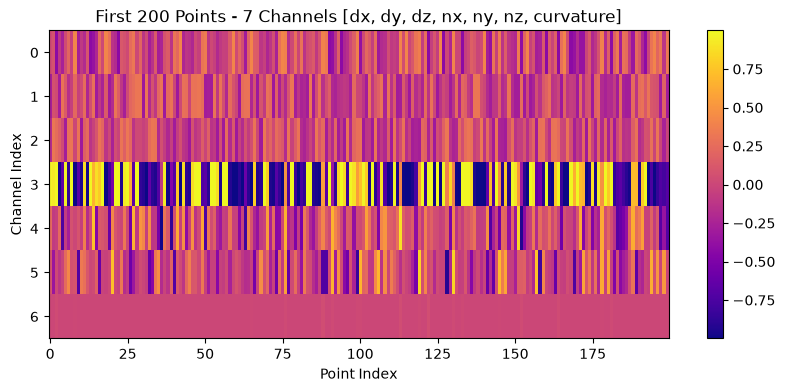

In [2]:
feat, target = generate_point_sample(seed=42, n_points=4096)
print(f"Point feature shape: {feat.shape} (7 channels x N points)")
print(f"Target outliers: {target.sum()} / {len(target)} ({100*target.sum()/len(target):.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(feat[:, :200], aspect='auto', cmap='plasma')
ax.set_title('First 200 Points - 7 Channels [dx, dy, dz, nx, ny, nz, curvature]')
ax.set_ylabel('Channel Index')
ax.set_xlabel('Point Index')
fig.colorbar(im, ax=ax)
plt.show()

## 3. Training Loop

In [3]:
epochs = 10
lr = 1e-3
model = PointNetClassifier(in_channels=7, hidden_dim=64).to(device)
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

best_loss = float('inf')
history = {'loss': [], 'precision': [], 'recall': []}

print(f"Starting PointNet training for {epochs} epochs...")
for epoch in range(1, epochs + 1):
    t0 = time.time()
    model.train()
    epoch_loss = 0.0
    n_samples = 10
    total_tp, total_fp, total_fn = 0, 0, 0
    
    for idx in range(n_samples):
        seed = epoch * 500 + idx
        feat, target = generate_point_sample(seed=seed, n_points=2048)
        
        inp_t = torch.from_numpy(feat).unsqueeze(0).to(device)
        target_t = torch.from_numpy(target).unsqueeze(0).to(device)
        
        optimizer.zero_grad()
        logits = model(inp_t)
        loss = criterion(logits, target_t)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        with torch.no_grad():
            preds = (torch.sigmoid(logits) > 0.5).squeeze(0).cpu().numpy()
            total_tp += int((preds & (target == 1)).sum())
            total_fp += int((preds & (target == 0)).sum())
            total_fn += int((~preds & (target == 1)).sum())
            
    avg_loss = epoch_loss / n_samples
    prec = total_tp / (total_tp + total_fp + 1e-8)
    rec = total_tp / (total_tp + total_fn + 1e-8)
    t_el = time.time() - t0
    
    history['loss'].append(avg_loss)
    history['precision'].append(prec)
    history['recall'].append(rec)
    
    marker = ''
    if avg_loss < best_loss:
        best_loss = avg_loss
        os.makedirs(os.path.dirname(DEFAULT_POINT_CHECKPOINT), exist_ok=True)
        torch.save(model.state_dict(), DEFAULT_POINT_CHECKPOINT)
        marker = ' [saved]'
        
    print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | Prec: {prec:.3f} | Rec: {rec:.3f} | {t_el:.1f}s{marker}")

Starting PointNet training for 10 epochs...
Epoch  1/10 | Loss: 0.5494 | Prec: 0.111 | Rec: 0.665 | 0.5s [saved]
Epoch  2/10 | Loss: 0.4086 | Prec: 0.641 | Rec: 0.879 | 0.5s [saved]
Epoch  3/10 | Loss: 0.3159 | Prec: 0.958 | Rec: 0.941 | 0.5s [saved]
Epoch  4/10 | Loss: 0.2493 | Prec: 0.867 | Rec: 0.978 | 0.5s [saved]
Epoch  5/10 | Loss: 0.1992 | Prec: 0.954 | Rec: 0.977 | 0.5s [saved]
Epoch  6/10 | Loss: 0.1794 | Prec: 0.959 | Rec: 0.967 | 0.5s [saved]
Epoch  7/10 | Loss: 0.1377 | Prec: 0.983 | Rec: 0.971 | 0.5s [saved]
Epoch  8/10 | Loss: 0.1277 | Prec: 0.980 | Rec: 0.974 | 0.5s [saved]
Epoch  9/10 | Loss: 0.1034 | Prec: 1.000 | Rec: 0.983 | 0.4s [saved]
Epoch 10/10 | Loss: 0.0850 | Prec: 0.997 | Rec: 0.996 | 0.5s [saved]


## 4. Precision & Recall Curves

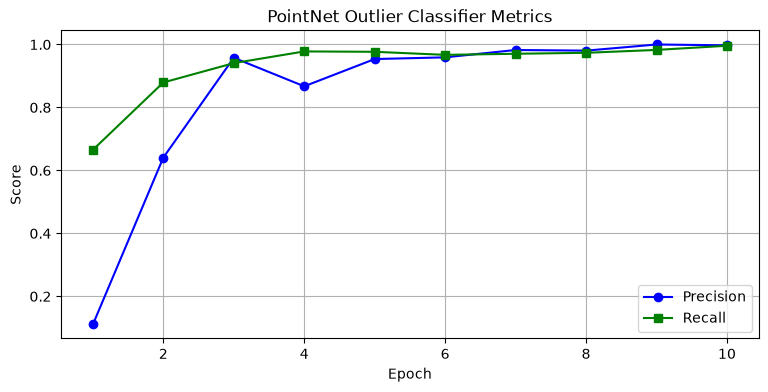

In [4]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, epochs + 1), history['precision'], 'b-o', label='Precision')
plt.plot(range(1, epochs + 1), history['recall'], 'g-s', label='Recall')
plt.xlabel('Epoch'); plt.ylabel('Score')
plt.title('PointNet Outlier Classifier Metrics')
plt.legend()
plt.grid(True)
plt.show()